# LightGBM API Demonstration

This notebook demonstrates the usage of custom utility functions built for real-time Bitcoin price analysis using the LightGBM framework.It leverages historical price data from the CoinGecko API, performs time-series feature engineering, and trains a regression model to forecast future prices.
## Notebook Objectives
This notebook focuses on:

* Fetching historical Bitcoin prices from the CoinGecko API

* Creating lag-based and time-based features

* Training a LightGBM regression model

* Evaluating prediction performance using standard metrics

* Visualizing actual vs. predicted Bitcoin prices

## References
* CoinGecko API Docs: https://www.coingecko.com/en/api

* LightGBM Documentation: https://lightgbm.readthedocs.io/

* scikit-learn Docs: https://scikit-learn.org/stable/documentation.html

## Citations
CoinGecko. (2024). CoinGecko API v3. Retrieved from https://www.coingecko.com/en/api/documentation

# 1. Setup and Imports

In [5]:
from LightGBM_utils import (
    fetch_bitcoin_price,
    create_features,
    train_lightgbm,
    evaluate_model,
    plot_predictions,
    fetch_bitcoin_price,
    process_price_data,
    save_to_csv,
    get_historical_bitcoin_data,
    calculate_moving_average,
    detect_trend,
    detect_anomalies_zscore,
    plot_price_with_moving_average,

)

import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## 2. Fetch Bitcoin Price Data

In [7]:
# Fetch current price from CoinGecko API
live_price = fetch_bitcoin_price()
print("Live Price Data:", live_price)

Live Price Data: {'timestamp': datetime.datetime(2025, 5, 18, 0, 23, 41, 87700), 'price': 103318}


In [9]:
# Convert price dict into DataFrame
df_price = process_price_data(live_price)
df_price

,timestamp,price
0,2025-05-18 00:23:41.087700,103318


In [11]:
df_price = fetch_bitcoin_price()
df_price = process_price_data(df_price)
save_to_csv(df_price, filepath="data/bitcoin_prices.csv")

print("Saved to 'bitcoin_prices.csv'")

Saved to 'bitcoin_prices.csv'


In [15]:
# Get last 30 days of historical BTC prices
df_hist = get_historical_bitcoin_data(days=365)
df_hist.head()

,timestamp,price
0,2024-05-19,66912.618614
1,2024-05-20,66252.712596
2,2024-05-21,71430.297002
3,2024-05-22,70189.835818
4,2024-05-23,69181.200857


In [17]:
# Compute 5-day moving average on historical data
df_ma = calculate_moving_average(df_hist, window_days=5)
df_ma.head()

,timestamp,price,moving_average
0,2024-05-19,66912.618614,66912.618614
1,2024-05-20,66252.712596,66582.665605
2,2024-05-21,71430.297002,68198.542737
3,2024-05-22,70189.835818,68696.366007
4,2024-05-23,69181.200857,68793.332977


In [19]:
# Analyze basic trend using linear regression slope
trend_result = detect_trend(df_ma)
print("Trend:", trend_result)

# Identify outliers in price movement
df_anom = detect_anomalies_zscore(df_ma)
df_anom[df_anom["anomaly"] == True].head()

Trend: upward


,timestamp,price,moving_average,z_score,anomaly


In [23]:
print(df_anom.columns)

Index(['timestamp', 'price', 'moving_average', 'z_score', 'anomaly'], dtype='object')


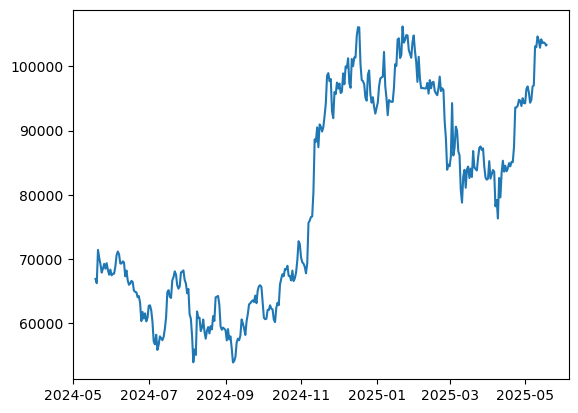

In [31]:
plt.plot(df_anom["timestamp"], df_anom["price"], label="Price")


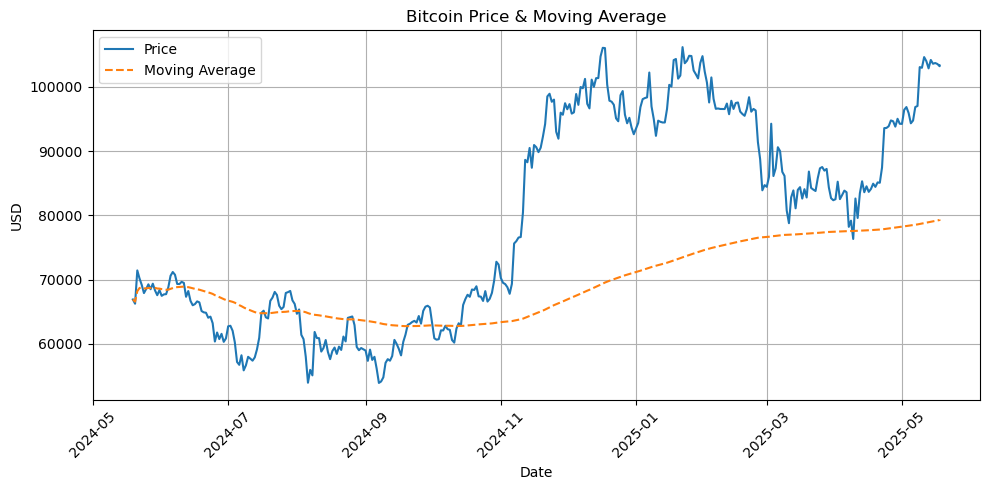

In [35]:
# # Visualize price + moving average line
# plot_price_with_moving_average(df_anom)
if "timestamp" in df_anom.columns and "date" not in df_anom.columns:
    df_anom["date"] = pd.to_datetime(df_anom["timestamp"]).dt.date
plot_price_with_moving_average(df_anom)
